Retrieving InsertionElectrodeDoc documents: 100%|██████████| 2774/2774 [00:02<00:00, 1355.02it/s]


average_voltage: 3.418653985871179
energy_grav: 456.2583414945248
energy_vol: 1568.2262481737887
capacity_grav: 133.25038940686866
capacity_vol: 462.02675437734047
max_delta_volume: 0.07652945265126816
stability_charge: 0.10874466362721943
stability_discharge: 0.09344139690869716
fracA_charge: 0.048194773546229114
fracA_discharge: 0.16232393148427837
2774


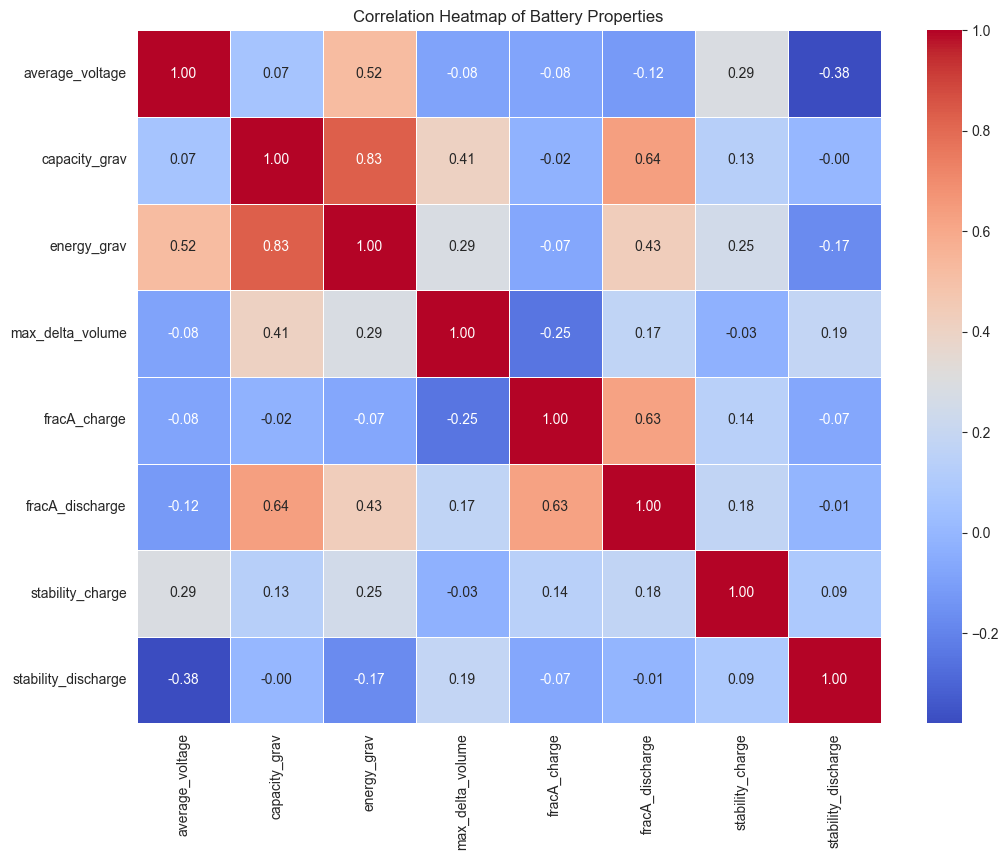


Data Size: 2774


In [3]:
# LITHIUM

from mp_api.client import MPRester
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


API_KEY = "4IeHY5jVcrgiKXNuAo6Jgs7yC0Z3hsli"
try:
    with MPRester(API_KEY) as mpr:
        # Query for Li-based cathode materials with high energy density
        docs = mpr.materials.insertion_electrodes.search(
        working_ion="Li",
       # average_voltage = (2.5, 8.0), stability_charge=(0.0, 0.15), # 0.1 > stability_charge (meV) starts to be unstable
        fields=[
            "battery_id", "formula_discharge", "average_voltage"
            , "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "stability_charge", "fracA_charge", "max_delta_volume", "stability_discharge", "fracA_discharge"
        ])

        Fields = "average_voltage", "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "max_delta_volume", "stability_charge", "stability_discharge", "fracA_charge", "fracA_discharge"

        def average_field(docs, field):
            vals = [getattr(d, field) for d in docs if getattr(d, field) is not None]
            return sum(vals) / len(vals)


        df = pd.DataFrame([doc.dict() for doc in docs])
        df.head(20)

        for f in Fields:
            avg = average_field(docs, f)
            print(f"{f}: {avg}")
        print(len(df))
        df.head(20)

         # Select only the numeric columns relevant to battery performance
    cols_to_analyze = ['average_voltage', 'capacity_grav', 'energy_grav',
                        'max_delta_volume',
                       'fracA_charge', 'fracA_discharge', 'stability_charge', 'stability_discharge']
    correlation_matrix = (df[cols_to_analyze].corr(method="spearman"))
    correlation_matrix.head()
    plt.figure(figsize=(12, 9))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Battery Properties")
    plt.show()
    print(f"\nData Size: {len(df)}")



except Exception as e:
    print(f"An error occurred: {e}")




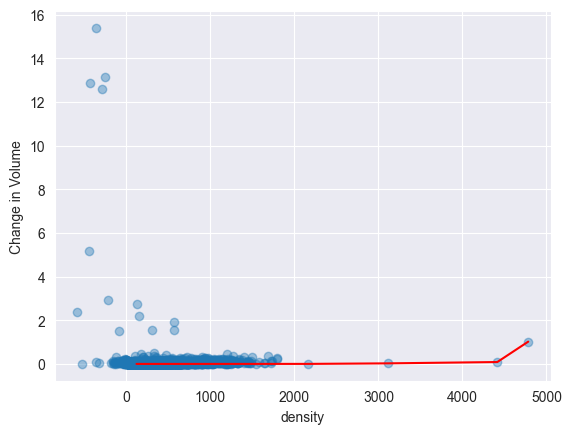

In [4]:
#Figure-Pareto-1
"""---- 1 ---- """

import matplotlib.pyplot as plt

"""
Density VS Max Delta Volume
"""

density = [doc.energy_grav for doc in docs] #verify that vaues correspond
maxChangeInVolume = [doc.max_delta_volume for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='density', ylabel='Change in Volume',):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(density, maxChangeInVolume)


mp-985585_Li
mp-976060_Li
mp-9244_Li
mp-1111688_Li
mp-850895_Li
mp-753080_Li
mp-759168_Li
mp-22417_Li
mp-25304_Li
mp-25967_Li
mp-26387_Li
mp-26403_Li
mp-26577_Li
mp-705448_Li
mp-752757_Li
mp-752923_Li
mp-756285_Li
mp-759520_Li
mp-759829_Li
mp-761130_Li
mp-764367_Li
mp-775438_Li
mp-779058_Li
mp-26347_Li
mp-26531_Li
mp-1012865_Li


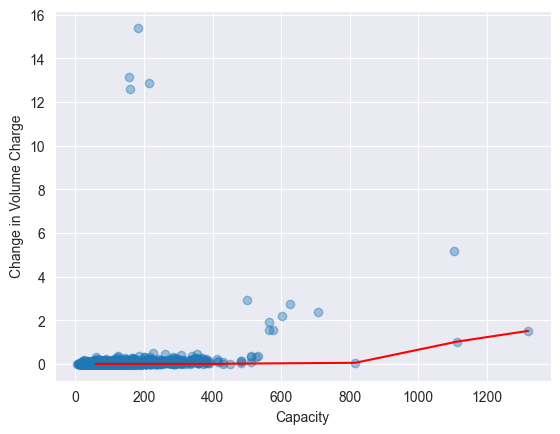

In [3]:
"""---- 2 ---- """

#Figure-Pareto-1

import matplotlib.pyplot as plt

"""
Capacity VS Max Delta Volume
"""

capacity = [doc.capacity_grav for doc in docs] #verify that vaues correspond
maxChangeInVolume = [doc.max_delta_volume for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='Capacity', ylabel='Change in Volume Charge',):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(capacity, maxChangeInVolume)


mp-756779_Li 
mp-807730_Li 
mp-801838_Li 
mp-752527_Li 
mp-799530_Li 
mp-776632_Li 
mp-1189643_Li 
mp-1345203_Li 
mp-729639_Li 
mp-756664_Li 
mp-770684_Li 
mp-26449_Li 
mp-705448_Li 
mp-752973_Li 
mp-771908_Li 
mp-821758_Li 
mp-1367296_Li 
mp-697827_Li 
mp-557395_Li 
mp-26525_Li 
mp-725039_Li 
mp-26480_Li 
mp-26007_Li 
mp-764912_Li 
mp-801665_Li 
mp-753895_Li 
mp-756319_Li 
mp-27060_Li 
mp-1219467_Li 
mp-27080_Li 
mp-4995_Li 
mp-787453_Li 
mp-1367753_Li 
mp-1013987_Li 
mp-26263_Li 
mp-504236_Li 
mp-770546_Li 
mp-757059_Li 
mp-25397_Li 
mp-1012879_Li 
mp-729641_Li 
mp-807977_Li 
mp-884044_Li 
mp-1374975_Li 
mp-754803_Li 
mp-755343_Li 
mp-697808_Li 
mp-756371_Li 
mp-9158_Li 
mp-831192_Li 
mp-763440_Li 
mp-867653_Li 
mp-29324_Li 
mp-26299_Li 
mp-26771_Li 
mp-985585_Li 
mp-25386_Li 
mp-25268_Li 
mp-1411949_Li 
mp-1333053_Li 
mp-1400737_Li 
mp-19131_Li 
mp-1120722_Li 
mp-18968_Li 
mp-1342258_Li 
mp-753758_Li 
mp-758209_Li 
mp-29868_Li 
mp-1185311_Li 
mp-766008_Li 
mp-1342745_Li 
mp-5127_Li 

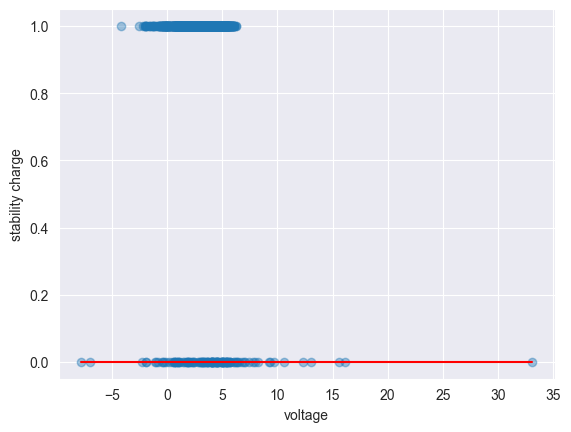

In [5]:
"""---- 3 ---- """

#Figure-Pareto-1

import matplotlib.pyplot as plt

"""
Voltage VS stability charged
"""

voltage = [doc.average_voltage for doc in docs] #verify that vaues correspond
stability = [doc.stability_charge < 0.2 for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='voltage', ylabel='stability charge',):
    '''Pareto frontier selection process'''
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_charge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_charge == pair[0]:

                        print(f"{id.battery_id} ") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(voltage, stability)


mp-8633_Li
mp-976060_Li
mp-8636_Li
mp-124_Li
mp-867343_Li
mp-623511_Li
mp-2074_Li
mp-80_Li
mp-2074_Li
mp-80_Li
mp-28_Li
On Pareto Front: 11


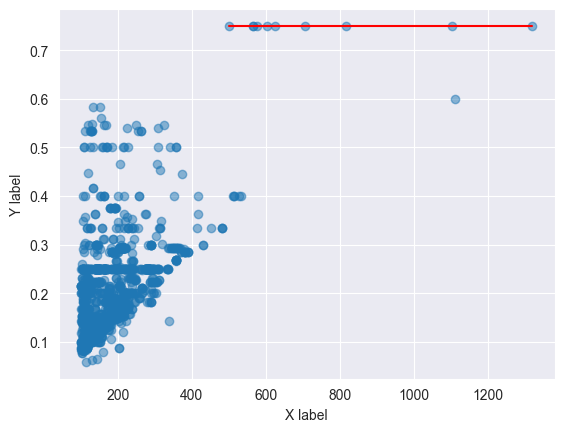

In [6]:
#Figure-Pareto-1
"""---- 1 ---- """

import matplotlib.pyplot as plt

"""
Density VS Max Delta Volume
"""

density = [doc.energy_grav for doc in docs] #verify that vaues correspond
maxChangeInVolume = [doc.max_delta_volume for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='density', ylabel='Change in Volume',):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(density, maxChangeInVolume)
